In [ ]:
from google.colab import files
uploaded = files.upload()

Saving brain_tumor_dataset.zip to brain_tumor_dataset.zip


In [ ]:
!unzip brain_tumor_dataset.zip

Archive:  brain_tumor_dataset.zip
   creating: brain_tumor_dataset/
   creating: brain_tumor_dataset/no/
  inflating: brain_tumor_dataset/no/1 no.jpeg  
  inflating: brain_tumor_dataset/no/10 no.jpg  
  inflating: brain_tumor_dataset/no/11 no.jpg  
  inflating: brain_tumor_dataset/no/12 no.jpg  
  inflating: brain_tumor_dataset/no/13 no.jpg  
  inflating: brain_tumor_dataset/no/14 no.jpg  
  inflating: brain_tumor_dataset/no/15 no.jpg  
  inflating: brain_tumor_dataset/no/17 no.jpg  
  inflating: brain_tumor_dataset/no/18 no.jpg  
  inflating: brain_tumor_dataset/no/19 no.jpg  
  inflating: brain_tumor_dataset/no/2 no.jpeg  
  inflating: brain_tumor_dataset/no/20 no.jpg  
  inflating: brain_tumor_dataset/no/21 no.jpg  
  inflating: brain_tumor_dataset/no/22 no.jpg  
  inflating: brain_tumor_dataset/no/23 no.jpg  
  inflating: brain_tumor_dataset/no/24 no.jpg  
  inflating: brain_tumor_dataset/no/25 no.jpg  
  inflating: brain_tumor_dataset/no/26 no.jpg  
  inflating: brain_tumor_datase

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = train_datagen.flow_from_directory(
    'brain_tumor_dataset/',
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    'brain_tumor_dataset/',
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 203 images belonging to 2 classes.
Found 50 images belonging to 2 classes.


In [ ]:
model = models.Sequential()

# Conv Layer 1
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
model.add(layers.MaxPooling2D(2,2))

# Conv Layer 2
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

# Conv Layer 3
model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

# Flatten
model.add(layers.Flatten())

# Dense Layers
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))  # binary classification

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 28s 4s/step - accuracy: 0.6010 - loss: 1.3819 - val_accuracy: 0.7600 - val_loss: 0.5625
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 25s 4s/step - accuracy: 0.7980 - loss: 0.5193 - val_accuracy: 0.7400 - val_loss: 0.5947
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 25s 4s/step - accuracy: 0.8177 - loss: 0.4765 - val_accuracy: 0.7600 - val_loss: 0.5442
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 41s 4s/step - accuracy: 0.8424 - loss: 0.4003 - val_accuracy: 0.7600 - val_loss: 0.5235
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 25s 4s/step - accuracy: 0.8719 - loss: 0.3310 - val_accuracy: 0.7400 - val_loss: 0.4691
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 24s 4s/step - accuracy: 0.8966 - loss: 0.2532 - val_accuracy: 0.8400 - val_loss: 0.3808
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 25s 4s/step - accuracy: 0.9507 - loss: 0.1333 - val_accuracy: 0.8400 - val_loss: 0.4809
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 25s 4s/step - accuracy: 0.9803 - loss: 0.0727 - val_accuracy: 0.9000 - val_loss: 0.3585
Epoch 9/

In [ ]:
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

In [ ]:
from tensorflow.keras import Model # Add this import
import tensorflow as tf # Ensure tf is imported

def get_gradcam(model, img_array, layer_name='conv3_last'):
    # Ensure the model is built before accessing its input/output attributes
    if not model.built:
        model.build(input_shape=(None,) + img_array.shape[1:])

    # Explicitly call the model with a dummy input to ensure its input/output tensors are fully resolved
    # This is a common workaround for Sequential models when using their inputs/outputs in functional API constructs.
    _ = model(tf.zeros(img_array.shape))

    grad_model = Model(
        inputs=model.input,
        outputs=[model.get_layer(layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_array)
        loss = preds[:, 0]

    grads       = tape.gradient(loss, conv_out)
    pooled      = tf.reduce_mean(grads, axis=(0,1,2))
    heatmap     = tf.nn.relu(conv_out[0] @ pooled[..., tf.newaxis])
    heatmap     = heatmap.numpy().squeeze()
    heatmap     = heatmap / (heatmap.max() + 1e-8)
    return heatmap

print('Grad-CAM function ready')

Grad-CAM function ready


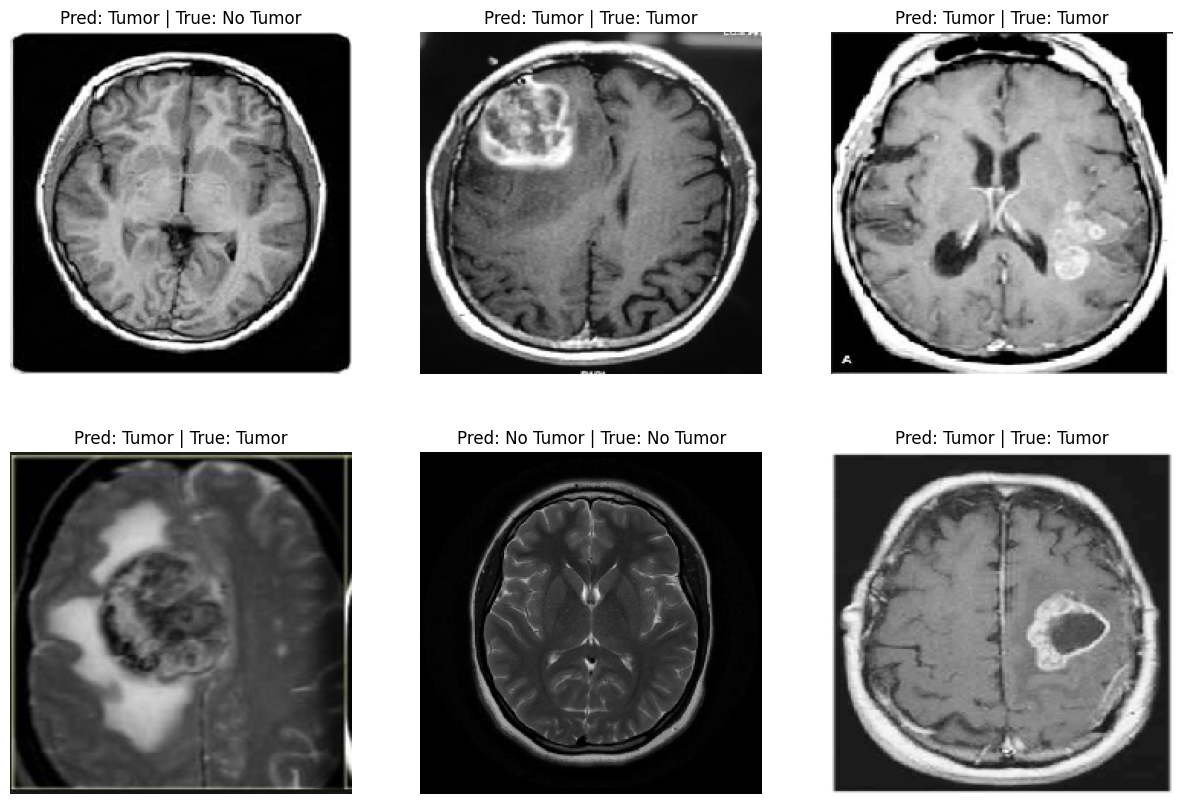

In [ ]:
import numpy as np # Import numpy

CLASS_NAMES = ['No Tumor', 'Tumor']

plt.figure(figsize=(15,10))

# Get a batch of images and labels from the validation data
imgs, labels = next(iter(val_data))

# Ensure we don't try to plot more images than available in the batch
num_images_to_plot = min(6, len(imgs))

for i in range(num_images_to_plot):
    img = imgs[i]
    inp = np.expand_dims(img, 0)

    prob = model.predict(inp, verbose=0)[0][0]
    pred = 'Tumor' if prob >= 0.5 else 'No Tumor'

    # safe handling
    label_value = int(labels[i])
    if label_value < len(CLASS_NAMES):
        true = CLASS_NAMES[label_value]
    else:
        true = "Unknown" # Fallback if label_value is out of bounds

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(f"Pred: {pred} | True: {true}")
    plt.axis('off')

plt.show()